<a href="https://colab.research.google.com/github/diegosolgtz-pixel/Analisis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
 # mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())
    # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En users la columna city tiene 469 valores ausentes, que representan casi 12% y churn_date tiene 6534 ausentes, lo cual es casi un 89%.
En usage faltan 50 valores en city, que son menos del 1%, en duration faltan 22076 que representan un 55% y por su parte en lenght faltan 17896, que es casi un 45%
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Ya que para las preguntas de negocio city no es una variable que parezca relevante, en ambos data sets los valores de city se pueden dejar como nulos, y lo mismo con churn date, los valores de churn pueden deberse a que solo el 11% de clientes cancelaron su linea y los demas siguen activos.
- Por otra parte, revisando los datos las llamadas tienen duration y los mensajes tienen lenght, por lo que es normal que tengamos esos faltantes, el problema es que la suma de ambos datos nos da 39,972 por lo que tenemos 28 datos faltantes para completar los 40,000 del data set, pero al ser una cantidad tan pequeña podriamos dejarlos como faltantes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print(users[['user_id','age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` presenta 4000 datos, que empiezan con la numeracion 10,000 y va aumentando de 1 en 1, hasta el 13,999 por lo que tenemos todos los usuarios sin faltantes.
- La columna `age` si presenta un problema grave y es que tienene valores extremos, el valor minimo de edad es de -999, hay que revisar esos datos.

In [ ]:
# explorar columnas numéricas de usage
print(usage[['id','user_id']].describe())

                id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000


- Las columnas `id` y `user_id`
- En user_id los datos caen en el mismo rango que los del data set users.
-En id podemos confirmar que tampoco hay faltantes.

In [ ]:

# explorar columnas categóricas de users

columnas_user = ['city', 'plan']
print(users[columnas_user].value_counts())



city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64


- La columna `city` tiene el problema de un dato con nombre '?'.
- En la columna `plan` tenemos 65 planes basicos y 31 premium que no sabemos de que ciudad son.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64


- La columna `type` nos muestra valores que sumando nos regresan los 40,000 datos que debemos tener.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- En la columna tenemos los sentinels -999 por lo que podriamos sustituirlos por el valor de la mediana o revisar si el porcentaje de datos es bajo para eliminarlos y evitar que sesguen el analisis
-  En el caso de los valores invalidos de city con el simbolo '?' se puede reemplazar por valores nulos o eliminar esos datos, ya que no llegan a 100.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])# completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'])

0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]


In [ ]:
años_registro = users['reg_date'].dt.year.unique()
print("Años únicos en reg_date:", sorted(años_registro))
print("Cantidad de años diferentes:", len(años_registro))

Años únicos en reg_date: [2022, 2023, 2024, 2026]
Cantidad de años diferentes: 4


In [ ]:
registros_2026 = (users['reg_date'].dt.year == 2026).sum()
print(f"Cantidad de registros con fecha 2026: {registros_2026}")

Cantidad de registros con fecha 2026: 40


En `reg_date`, eixten registros desde 2022 hasta 2024, pero tambien hay 40 valores imposibles de 2026. haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'])

0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]


In [ ]:
print("\nDistribución por año en usage:")
print(usage['date'].dt.year.value_counts().sort_index())


Distribución por año en usage:
2024.0    39950
Name: date, dtype: int64


En `date`, solo hay valores de 2024 pero faltan 50 datos. haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Hay 40 fechas del año 2026 cuando los datos llegan hasta 2024, ya que son pocos podemos eliminarlos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users.loc[users['age'] == -999, 'age'] = np.nan
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users.loc[users['city'] == '?', 'city'] = np.nan

# Verificar cambios
print("Valores '?' restantes:", (users['city'] == '?').sum())

print("Valores únicos en city:")
print(users['city'].value_counts(dropna=False))



Valores '?' restantes: 0
Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = np.nan

# Verificar cambios
print("Valores '2026' restantes:", (users['reg_date'].dt.year == 2026).sum())
print("Valores únicos en reg_date:")
print(users['reg_date'].value_counts(dropna=False))

Valores '2026' restantes: 0
Valores únicos en reg_date:
NaT                              40
2023-03-31 06:21:20.120030008     1
2024-06-20 09:50:54.463615904     1
2022-05-22 00:23:45.956489122     1
2022-04-23 06:22:24.936234060     1
                                 ..
2022-07-29 04:44:06.661665416     1
2022-02-22 00:36:43.750937734     1
2022-10-31 09:22:49.242310580     1
2022-09-24 16:46:48.702175544     1
2022-03-28 12:38:20.975243811     1
Name: reg_date, Length: 3961, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print("Relación entre 'type' y valores nulos en 'duration':")
tabla_duration = pd.crosstab(usage['type'], usage['duration'].isna(), margins=True)
print(tabla_duration)

Relación entre 'type' y valores nulos en 'duration':
duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print("\nRelación entre 'type' y valores nulos en 'length':")
tabla_length = pd.crosstab(usage['type'], usage['length'].isna(), margins=True)
print(tabla_length)


Relación entre 'type' y valores nulos en 'length':
length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length'
La relacion entre valores nulos en type obedece a que si son calls tienen duration, mientras que si son text tienen lenght, por lo tanto se pueden dejar esos valores en blanco ya que es normal que un mensaje de texto no tenga duracion, ni una llamada tenga longitud. El unico detalle es que hay 16 text con valores en duration y 12 llamadas que tienen longitud.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas



# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',        # Total de mensajes por usuario
    'is_call': 'sum',        # Total de llamadas por usuario
    'duration': 'sum'        # Total de minutos por usuario
}).reset_index()
# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns= {
    'is_text' : 'cant_mensajes',
    'is_call' : 'cant_llamadas',
    'duration' : 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on =['user_id'])

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("Resumen estadístico de variables numéricas:")
print(user_profile[columnas_numericas].describe())

Resumen estadístico de variables numéricas:
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  3999.000000    3999.000000    3999.000000           3999.000000
mean     48.124531       5.524381       4.478120             23.317054
std      17.692032       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      47.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [ ]:
# Distribución porcentual del tipo de plan
print("\nDistribución porcentual por tipo de plan:")
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100
print(distribucion_plan.round(2))


Distribución porcentual por tipo de plan:
Basico     64.87
Premium    35.13
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

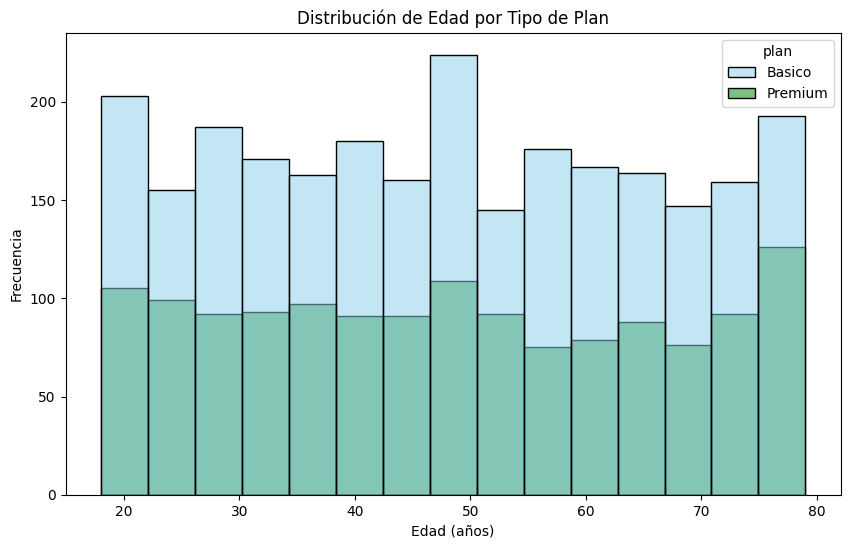

In [ ]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], bins=15)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
-  Tenemos una distribucion de usuarios de entre 18 a 79 años de edad, y donde tenemos la mayor concentracion, la cual pasa de los 200 usuarios es en el rango de entre 47 a 51 años, tambien se observa que la mayor parte de nuestros usuarios tiene contratado el plan basico, pero los usuarios que más contratan el plan premium son los que tienen entre 75 y y 79 años.

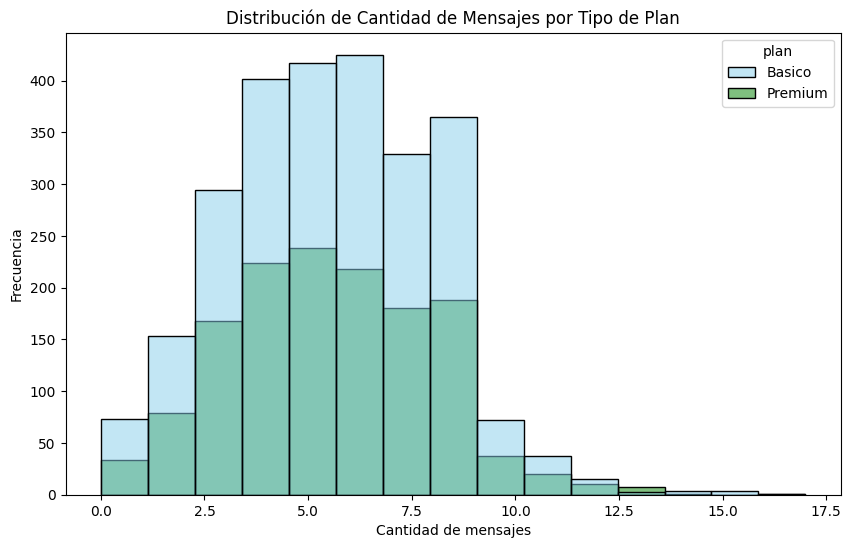

In [ ]:
# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=15)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- Se observa que la distribución esta sesgada a la derecha, ya que aunque la mayoria de usuarios envia 9 mensajes o menos, algunos usuarios envian hasta 17. También podemos concluir que los usuarios en general envian entre 4 y 7 mensajes sin importar el plan ya que ahi es donde podemos observar la mayor concentracion de usuarios.

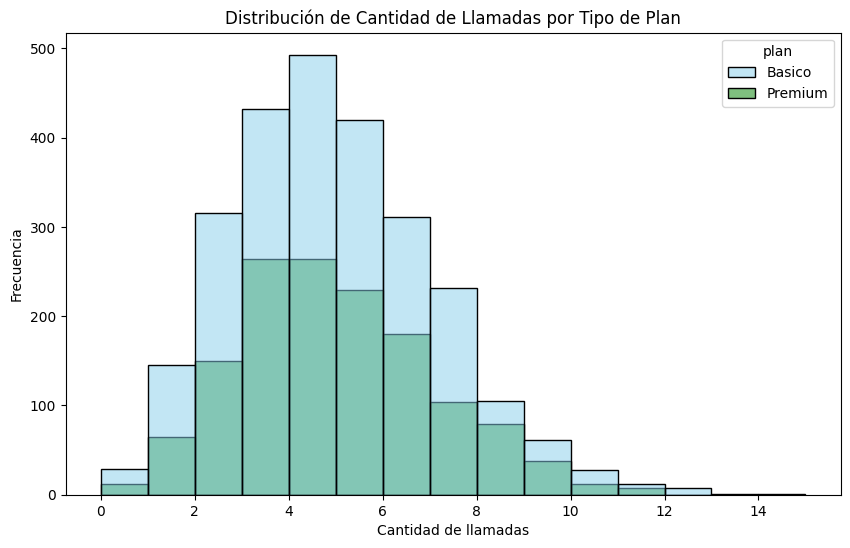

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=15)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- EN el grafico podemos observar que esta sesgado a la derecha ya que aunque la mayor parte de los usuarios hacen entre 4 y 5 llamadas, algunos relizan hasta 15. El comportamiento de los usuarios es muy similar sin importar el tipo de plan.

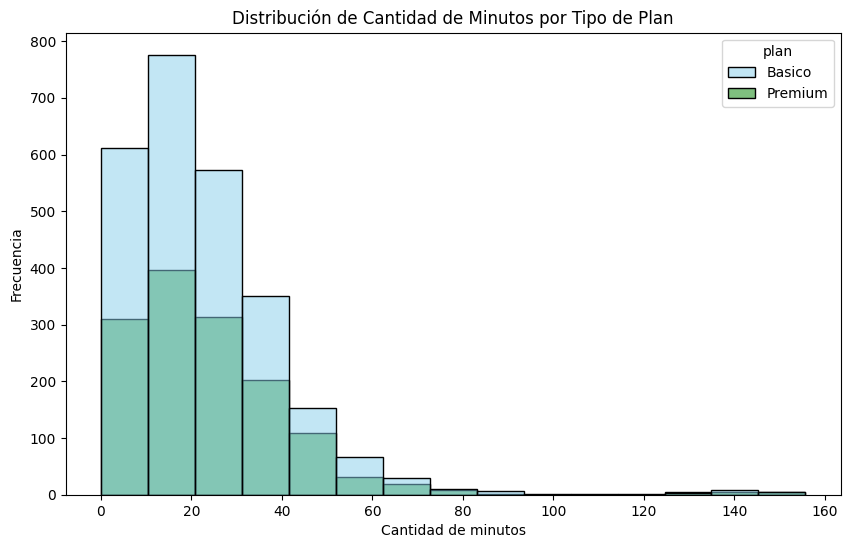

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=15)
plt.title('Distribución de Cantidad de Minutos por Tipo de Plan')
plt.xlabel('Cantidad de minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Se obrseva una vez más un sesgo a la derecha por personas que pasan entre 125 hasta casi 160 minutos en sus llamadas, mientrs que la mayor concentracion de usuarios (780 arpoximadamente) pasa entre 10 y 22 minutos en llamadas. Con esta grafica queda claro que en todos los aspectos los usuarios tienen comportamientos similares, y que los usuarios de plan basico solo tienen frecuencias mas altas ya que hay un mayor numero de usuarios con ese plan que con el premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

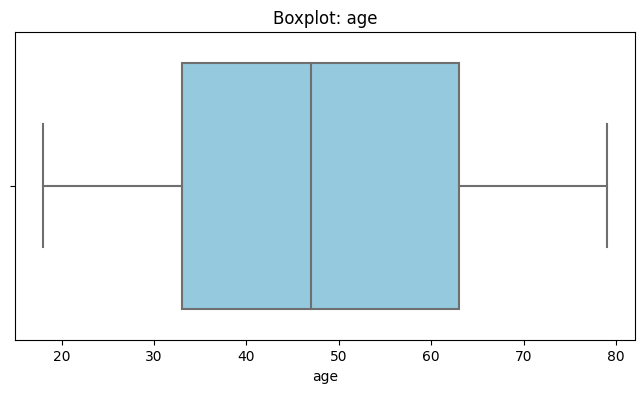

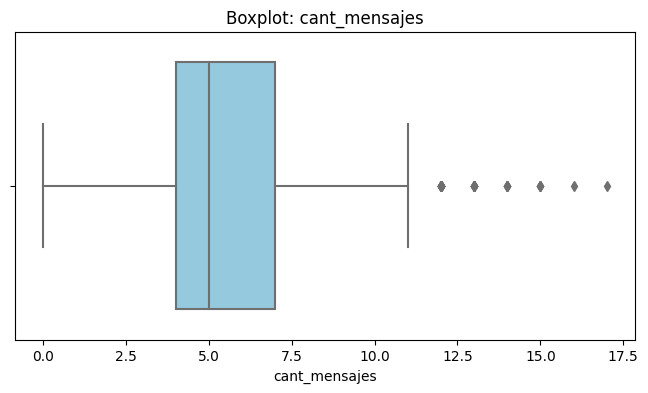

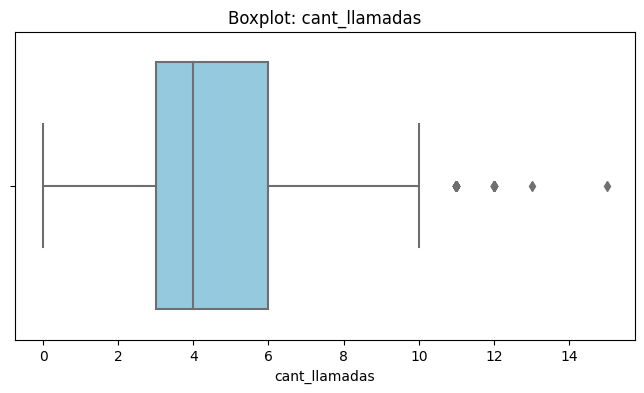

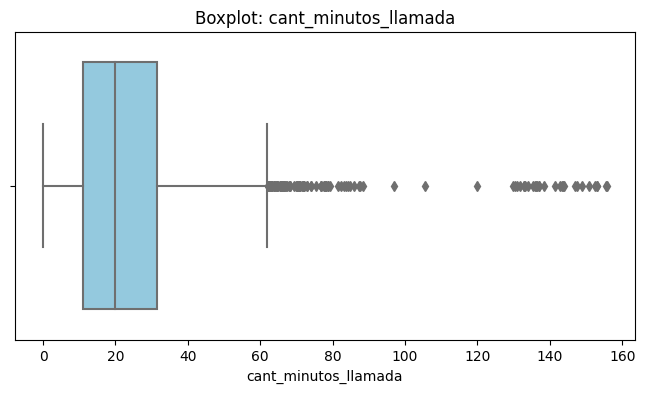

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: No presenta outliers
- cant_mensajes: Presenta outliers que van del 12 al 27
- cant_llamadas: Presenta outliers wue llegan al 15
- cant_minutos_llamada: Es la que presenta outlires más extremos

In [ ]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR= Q3 - Q1
    lower= Q1 - 1.5 * IQR
    upper= Q3 + 1.5 * IQR

    print(f"\n{col}:")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Límite inferior: {lower:.2f}")
    print(f"  Límite superior: {upper:.2f}")
    print(f"  Valor máximo en datos: {user_profile[col].max():.2f}")



cant_mensajes:
  Q1: 4.00
  Q3: 7.00
  IQR: 3.00
  Límite inferior: -0.50
  Límite superior: 11.50
  Valor máximo en datos: 17.00

cant_llamadas:
  Q1: 3.00
  Q3: 6.00
  IQR: 3.00
  Límite inferior: -1.50
  Límite superior: 10.50
  Valor máximo en datos: 15.00

cant_minutos_llamada:
  Q1: 11.12
  Q3: 31.41
  IQR: 20.30
  Límite inferior: -19.32
  Límite superior: 61.86
  Valor máximo en datos: 155.69


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? El valor mas extremo es de 17 lo cual es un valor que puede ser real, por lo que me parece que es mejor mantener los outliers.
- cant_llamadas: mantener o no outliers, porqué? El valor maximo es de 15 lo cual al igual que con los mensajes es un valor posible, puede que en ambos casos solosignifique que hay usuarios que son mas activos, seria normal si su giro profesional involucra mayor comunicacion por medio de mensajes o llamadas, por esto mismo me parece mejor mantenerlos que quitar dichos valores.
- cant_minutos_llamada: mantener o no outliers, porqué? En este caso hasta el 75% de las personas hablan hasta 31 minutos, el valor maximo es de una llamada de 2 horas y media, por my extremo que parezca, si tomamos en cuenta que hay llamadas como las que realizas por algun tema de soporte, como por ejemplo con instituciones bancarias, es usual que te tome mucho tiempo llegar a una resolucion, por lo que considero que es mejor dejar todos los valores.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'
user_profile.loc[(user_profile['cant_llamadas'] < 10) &
                 (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'
user_profile.loc[(user_profile['cant_llamadas'] < 5) &
                 (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Adulto Mayor,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'
user_profile.loc[user_profile['age'] < 60, 'grupo_edad'] = 'Adulto'
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Adulto Mayor,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

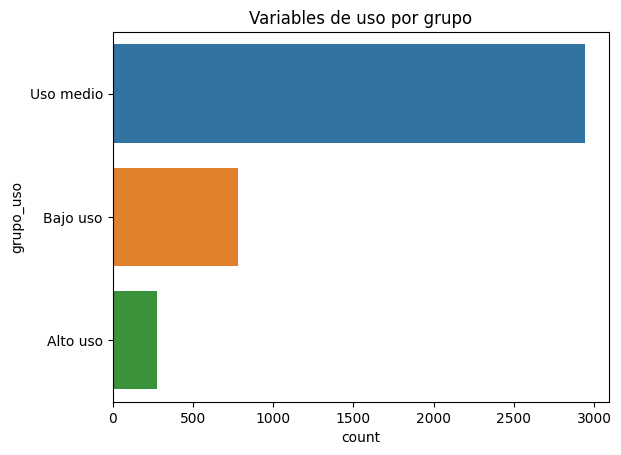

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, y='grupo_uso', order=user_profile['grupo_uso'].value_counts().index)
plt.title('Variables de uso por grupo')
plt.show()


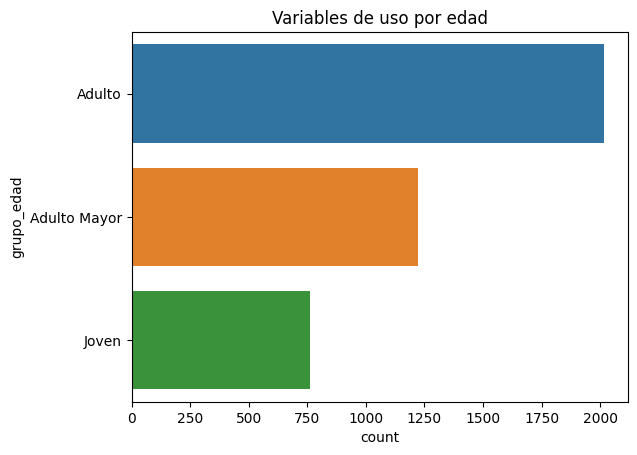

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, y='grupo_edad', order=user_profile['grupo_edad'].value_counts().index)
plt.title('Variables de uso por edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Los datos presentaban algunos errores en sus datos, la columna city mostraba valores con el simbolo '?' que fueron reemplazados por NaN, ya que en users solo representaban un 12% de faltantes, y en usage menos de un 1%, y no era posible definir de que ciudad era cada dato.
- Por otro lado la columna de age tenia un problema de sentinels '-999', los cuales se reemplazaron por la mediana.
- En churn_date se encintraron 6534 ausentes, lo cual es casi un 89%.Esto porque solo el 11 % abandono el servicio y ademnas al no ser relevante para este analisis se deja dejaron asi.
- Por otro lado en duration faltan 22076 que representan un 55% y por su parte en lenght faltan 17896, que es  un 45%, la relaion es que calls tienen duration y los text tienen lenght, por lo que es normal y ademas tampoco afecta al analisis.
- Por ultimo los formatos de fecha se encontraban como numero, asi que se les cambio el formato a fecha en los datasets de usage y users.

🔍 **Segmentos por Edad**

- Al segmentar por edad los clientes, se observa que el 50% de nuestros usuarios son adultos (de entre 30-59 años) por lo que son nuestro segmento mas importante, mientras que el de los jovenes (menores de 30 años), es casi 3 veces menor al de adultos.
- Por otro lado si tomamos en cuenta el segmento de adultos mayores, el 80% de nuestros usuarios son adultos, la ventaja es que implica que tienen un ingreso más estable, y valdria la pena mantener el nivel de servicio para no perderlos.

📊 **Segmentos por Nivel de Uso**
- Por otro lado tambien segmentamos por nivel de uso a los usuarios, dividiendo el uso en alto, medio y bajo.
- Lo que arroja el analisis es que 3000 usuarios, lo que representa el 75% caen en un uso medio, lo interesante es que sin importar en que nivel de uso esten, la mayor cantidad de llamadas es de 15 y de mensajes 17, y el plan basico es de 100 para cada uno, lo que se traduce en que realmente solo las personas que hacen llamadas y se exceden de 100 minutos necesita el plan premium que es de 500.
-

**Outliers**
Al analizar por usuario la cantidad de mensajes enviados, la cantitad de llamda y la duracion total en llamadas, se encontraron outliers en cada uno de los graficos. Esto implica que algunos pocos usuarios utilizan en mayor medida los servicios. Ya que a pesar de salirse de los parametros de comportamientos normales, son datos que son muy posibles y no errores, ademas los planes van de 100(plan basico) a 500(plan premium) mensajes y llamadas.


💡 **Recomendaciones**
- Para los usuarios que presentan outliers en la duracion de llamadas mayores a 100 minutos hacer una campaña para subirlos al plan premium si no cuentan con el, ya que les conviene para no generar cargos adicionales.
- Analizar por que razon los jovenes casi no contratan nuestros servicios, es posible que sea por la cantidad tan pequeña de datos que ofrece el plan basico, en el contexto global es normal que el comportamiento de los jovenes esta más orientado al uso de redes sociales que hacer llamadas y enviar mensajes. Tal vez valga la pena crear un plan para ese nicho ofreciendoles algo llamativo como mayor cantidad de gb para navegaion y menos mensajes y llamadas.
- Hacer un cruce de informacion para ver si los adultos y adultos mayores que se encuentran en el plan premium realmente lo necesitan o sugerir que se bajen al plan basico, es mejor retener un cliente por mucho tiempo con un plan menor que arriesgarse que se de cuenta de que gasta mucho dinero en un plan que no necesita y abandone el servicio molesto.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`